## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO. SUBMIT A PDF THAT HAS THE WRITTEN ANSWERS WITH THIS COLAB**

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.



2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.

3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?

4. What difficulties did you encounter in obtaining the data?

5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?




1: We (Julia Kim and myself) want our model to provide real-time visual guidance via question answering for blind or other visually impaired individuals. It should assist them with safety information (e.g. "Is there a car in front of me?"), as well as other forms of guidance (e.g. "What items are on this menu?" or "Where are the pants in the store?"). The novelty that our model wil add to existing research is an 'urgency/effort detection layer'. Our model will triage prompts to determine how urgent they are, and will adjust reasoning effort vs speed based on the urgency. For example, if the user question is "Car?" then the model will tone down its reasoning level to answer more quickly. For less urgent questions, such as "Which direction is the bank from here?" our model will spend more time reasoing, prioritizing accuracy over speed. For low-urgency questions which are of the types that VLMs usually have difficulty with, such as reading text, our model will do a best-of-K approach in addition to high reasoning effort, picking the response that will be the most accurate and useful to a visually impaired individual.

2: While both Ego4D and ProjectAria have their uses, we have determined that the best dataset for achieving our goals is the EgoBlind dataset. It is a large dataset of egocentric video taken BY visually impaired individuals, along with their accompanying questions regarding the situations in which they found themselves. As such, it is representative of the type of videos that will likely be catpured by visually impaired videos trying to use a model for help. Namely, objects tend to be off-center, camera focus is poor, and camera shake is severe in some cases. Additionally, EgoBlind has 3 human answers for most of the questions, and 1-2 on the rest, so the model will be exposed to a larger array of useful answers, which is useful in situations where there is not a single correct answer (such as in situations where the prompt was ambiguous). The only downside I can think of for EgoBlind is that it is medium-to-smaller-sized compared to some more popular VLM datasets, with only about 1,300 videos and about 5,000 questions. However, given our limited compute resources, this should not be too much of an issue in creating our proof-of-concept prototype.

3: The input modalities are video (with sound) and the textual transcription of the user questions. Our output modality will be a textual response to the user's queries, which can later be transcribed to a verbal response via text-to-speech software. We choose to output as text because our datapoints' output values are textual, so this will make training and evaluation easier. There are not really additional modalities that could be captured by a generic phone camera or GoPro other than those listed above.

4: The process of data acquisition was rather smooth, although the second or third human answers to some the questions are withheld from the publicly available dataset by the authors. Once we have trained the model I will send it to the dataset authors, who will evaluate our model against the 'hidden' answers as a form of validation.

5: Representation: We are focusing on representation fusion to address the heterogeneity of our data. The EgoBlind dataset contains high-noise visual elements (e.g. extreme blur) that standard encoders discard. We plan to fuse 'motion stability' representations with 'linguistic intent' representations. By integrating these modalities, we can represent urgency as a distinct concept, where high visual instability and short, urgent text queries are mapped to a safety-critical representation, rather than just being treated as low quality data.

Alignment: We face a continuous alignment challenge due to temporal latency. In blind egocentric scenarios, a user often asks "What was that?" after a collision or event has occurred. A standard one-to-one alignment where the current frame corresponds to the current question fails here. We will design our dataset loader to align the discrete text query with a continuous window of the preceding 3 seconds of video, capturing the causal link between the past visual event and the current spoken query.

Reasoning: Our project explicitly targets the structure of inference. Standard VQA uses a fixed inference path for all queries. We are addressing this by modeling a dynamic structure: a 'fast path' (single-step detection) for safety concepts, and a 'slow path' (multi-step composition and best-of-k responses) for assistive description. We will annotate our dataset (probably using an LLM due to the number of questions in the dataset) to support this split, allowing the model to switch inference paradigms based on urgency.

Generation: We are categorizing our generation challenge into two sub-tasks. For urgent queries, the goal is summarization; that is, reducing complex visual scenes into the most salient, high-entropy warning (e.g., "Stop, car"). For non-urgent queries, the goal is translation; that is, translating visual details into navigationally useful text. We will sturcture our reward function to reflect this dichotomy, penalizing verbose generation in safety scenarios.

Transference: We are employing model induction to optimize our inference pipeline. We will maintain our individual models, a lightweight unimodal 'urgency detector' and the heavy multimodal VLM, separately. We will transfer the urgency prediction from the lightweight model to the VLM, effectively 'inducing' the large model to fundamentally alter its behavior (switching from a fast, low-reasoning generation path to a computation-heavy reasoning and best-of-k path) based on the transferred signal, without needing to retrain the foundation model.

Quantification: We need to quantify the dimensions of heterogeneity within the dataset. EgoBlind contains distinct clusters of question types, which may help us in our urgency classification (although it also may also actually hinder us if the split between urgent and non-urgent is uncorrelated with question type). We anticipate needing disjoint evaluation metrics, including quantifying latency for urgent question while using the standard semantic similarity metrics for non urgent questions.

(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?  


In [14]:
!pip3 install opencv-python

  Using cached numpy-2.2.6-cp314-cp314-macosx_15_0_arm64.whl
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas 3.0.0 requires numpy>=2.3.3; python_version >= "3.14", but you have numpy 2.2.6 which is incompatible.


In [ ]:
import cv2
import os
import csv
import numpy as np
import pandas as pd
import subprocess

# Configuration
PROJECT_DIR = "."
VIDEO_DIR   = os.path.join(PROJECT_DIR, "split_0")
CSV_PATH    = os.path.join(PROJECT_DIR, "train.csv")
FRAME_DIR   = os.path.join(PROJECT_DIR, "extracted_frames")
AUDIO_DIR   = os.path.join(PROJECT_DIR, "extracted_audio")
FLOW_DIR    = os.path.join(PROJECT_DIR, "extracted_flow")
os.makedirs(FRAME_DIR, exist_ok=True)
os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(FLOW_DIR,  exist_ok=True)

# Loads csv
df = pd.read_csv(CSV_PATH)
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} cols")
print(df.head(3))

# Extracts frames at 1 fps
def extract_frames(video_path, out_dir, fps=1):
    """Extract frames at `fps` frames-per-second."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"  [WARN] Cannot open {video_path}")
        return 0
    orig_fps = cap.get(cv2.CAP_PROP_FPS) or 30
    interval = max(1, int(round(orig_fps / fps)))
    idx, saved = 0, 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % interval == 0:
            fname = os.path.join(out_dir, f"frame_{saved:05d}.jpg")
            cv2.imwrite(fname, frame)
            saved += 1
        idx += 1
    cap.release()
    return saved

# Runs on a few videos to demonstrate
demo_videos = sorted(os.listdir(VIDEO_DIR))[:5]   # first 5 videos
for vname in demo_videos:
    vpath = os.path.join(VIDEO_DIR, vname)
    vid_frame_dir = os.path.join(FRAME_DIR, vname.replace(".mp4", ""))
    os.makedirs(vid_frame_dir, exist_ok=True)
    n = extract_frames(vpath, vid_frame_dir, fps=1)
    print(f"  {vname}: extracted {n} frames @ 1 fps")

# Extracts audio (ffmpeg -> wav)
def extract_audio(video_path, out_path):
    """Extract mono 16kHz WAV audio from a video file."""
    cmd = [
        "ffmpeg", "-y", "-i", video_path,
        "-vn", "-acodec", "pcm_s16le", "-ar", "16000", "-ac", "1",
        out_path
    ]
    result = subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return result.returncode == 0

for vname in demo_videos:
    vpath = os.path.join(VIDEO_DIR, vname)
    apath = os.path.join(AUDIO_DIR, vname.replace(".mp4", ".wav"))
    ok = extract_audio(vpath, apath)
    tag = "OK" if ok else "FAIL"
    print(f"  Audio {vname}: {tag}")

# Extracts tex features (question stats)
df["q_word_count"] = df["question"].astype(str).apply(lambda s: len(s.split()))
df["q_char_count"] = df["question"].astype(str).apply(len)
print(f"\nQuestion length stats:\n{df['q_word_count'].describe()}")

# Extracts optical flow magnitude (motion proxy)
def mean_optical_flow(video_path, max_pairs=30):
    """Compute mean optical-flow magnitude over sampled frame pairs."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
    ret, prev = cap.read()
    if not ret:
        cap.release()
        return None
    prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)
    magnitudes = []
    count = 0
    while count < max_pairs:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        flow = cv2.calcOpticalFlowFarneback(
            prev_gray, gray, None, 0.5, 3, 15, 3, 5, 1.2, 0
        )
        mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        magnitudes.append(mag.mean())
        prev_gray = gray
        count += 1
    cap.release()
    return float(np.mean(magnitudes)) if magnitudes else None

print("\nOptical-flow (motion) magnitudes for demo videos:")
for vname in demo_videos:
    vpath = os.path.join(VIDEO_DIR, vname)
    m = mean_optical_flow(vpath)
    print(f"  {vname}: mean flow mag = {m:.3f}" if m else f"  {vname}: N/A")

print("\n--- Modality extraction complete ---")


Loaded: 2746 rows, 9 cols
   video_name question_id                                        question  \
0           0   v_00000_1  Is the driver looking at me or facing forward?   
1           0   v_00000_2            Is everything secure inside the car?   
2           0   v_00000_3             How do I lower or raise the window?   

                                          answer0  \
0                   The driver is facing forward.   
1                                            Yes.   
2  Use the window control button on the car door.   

                                             answer1  \
0                                    Facing forward.   
1                                                NaN   
2  The door on your left has a press or rocker op...   

                            answer2 answer3                           type  \
0             He is facing forward.     NaN  communication and interaction   
1                               NaN     NaN                safety warni

The first difficulty was around bridging the gap between the dataset's format and what the extraction code expected. The video_name column in train.csv contains plain integers (like 0, 1, 2) but the actual video files are named with zero-padded strings (like 00000.mp4, 00001.mp4), so we had to format them manually.

On top of that, in the interest of saving space and time, I downloaded only the split_0 folder for this task, but it contains only videos 0 through 92, while the CSV (which is used for all 10 splits) references hundreds more, so random sampling would silently pick videos that didn't exist on disk. I had to filter the dataframe down to the available range before doing anything.

On the code side, scikit-learn had renamed the TSNE parameter from n_iter to max_iter in a recent version, which caused a crash with no obvious explanation since most online documentation and Stack Overflow answers still reference the old name. This was a recurring theme. Version mismatches between installed packages made a lot of existing reference material unreliable.

The optical flow extraction also posed challenges. Because the videos were filmed by visually impaired users, extreme camera shake and motion blur are the norm, which means the Farneback algorithm returns high magnitudes across almost all frames. This makes it harder to use optical flow as a discriminative feature, since the baseline motion level is already elevated even in "calm" scenes. This is an inherent property of the dataset rather than a bug, but it's something we'll need to account for when using motion features downstream.

(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use differenrt distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

In [ ]:
# Packages (feel free to include more if needed)!
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs
import cv2, os

# Data Distribution

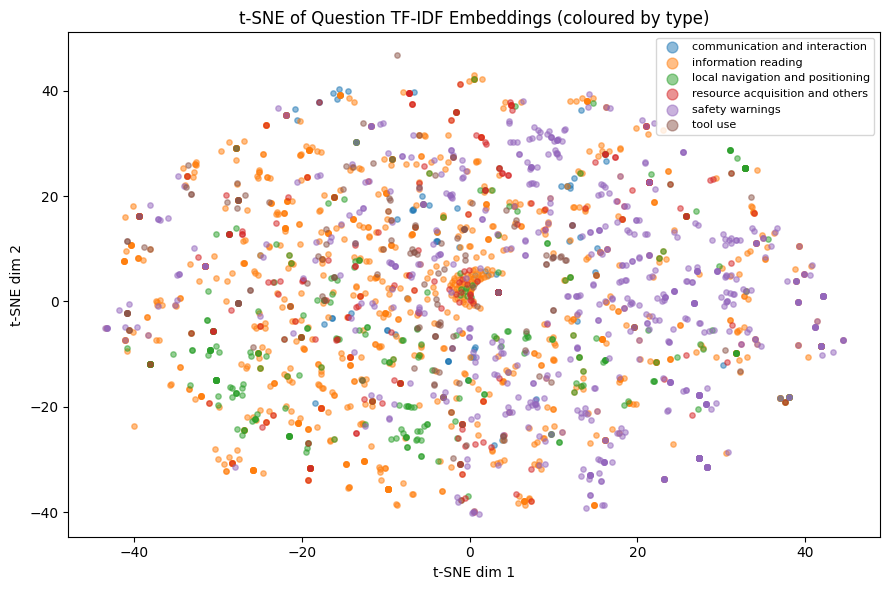

In [ ]:
def visualize_data_distribution(df, video_dir="split_0"):
    # TF-IDF t-SNE
    vectorizer = TfidfVectorizer(max_features=200, stop_words="english")
    X = vectorizer.fit_transform(df["question"].astype(str)).toarray()
    labels = df["type"].astype(str).values

    tsne = TSNE(n_components=2, perplexity=30, max_iter=500, random_state=42)
    emb = tsne.fit_transform(X)

    plt.figure(figsize=(9, 6))
    for lbl in sorted(set(labels)):
        mask = labels == lbl
        plt.scatter(emb[mask, 0], emb[mask, 1], label=lbl, alpha=0.5, s=15)
    plt.title("t-SNE of Question TF-IDF Embeddings (coloured by type)")
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.legend(fontsize=8, markerscale=2)
    plt.tight_layout()
    plt.savefig("tsne_question_embeddings.png", dpi=150)
    plt.show()

# Run
df = pd.read_csv("train.csv")
visualize_data_distribution(df)


# Samples

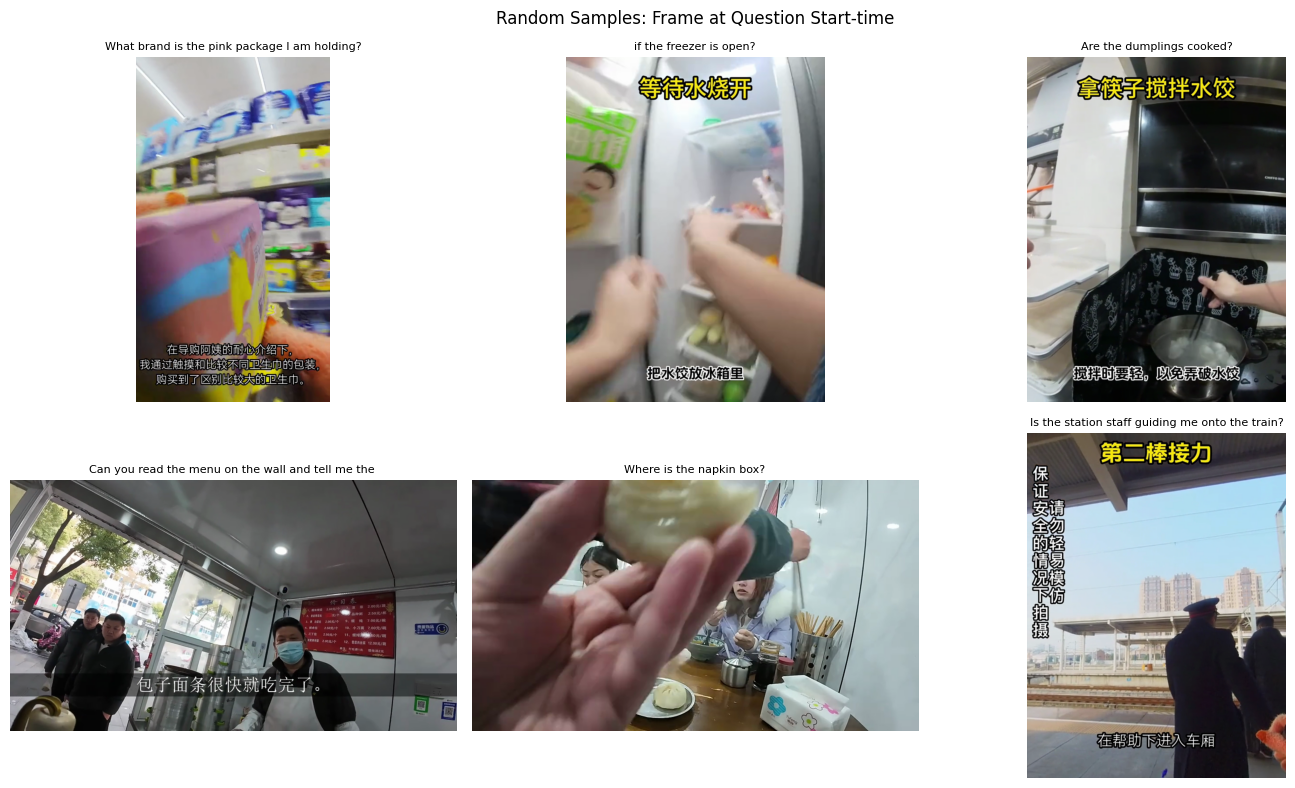

In [ ]:
def visualize_samples(df, video_dir="split_0", num_samples=6):
    available = df[df["video_name"].between(0, 92)]
    samples = available.sample(n=min(num_samples, len(available)), random_state=42)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, (_, row) in zip(axes.flat, samples.iterrows()):
        vpath = os.path.join(video_dir, f"{int(row['video_name']):05d}.mp4")
        cap = cv2.VideoCapture(vpath)
        # seek to question start-time
        start_s = float(row.get("start-time/s", 0))
        cap.set(cv2.CAP_PROP_POS_MSEC, start_s * 1000)
        ret, frame = cap.read()
        cap.release()
        if ret:
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(row["question"][:50], fontsize=8, wrap=True)
        ax.axis("off")
    plt.suptitle("Random Samples: Frame at Question Start-time", fontsize=12)
    plt.tight_layout()
    plt.savefig("sample_frames.png", dpi=150)
    plt.show()

visualize_samples(df)

# Input Distribution

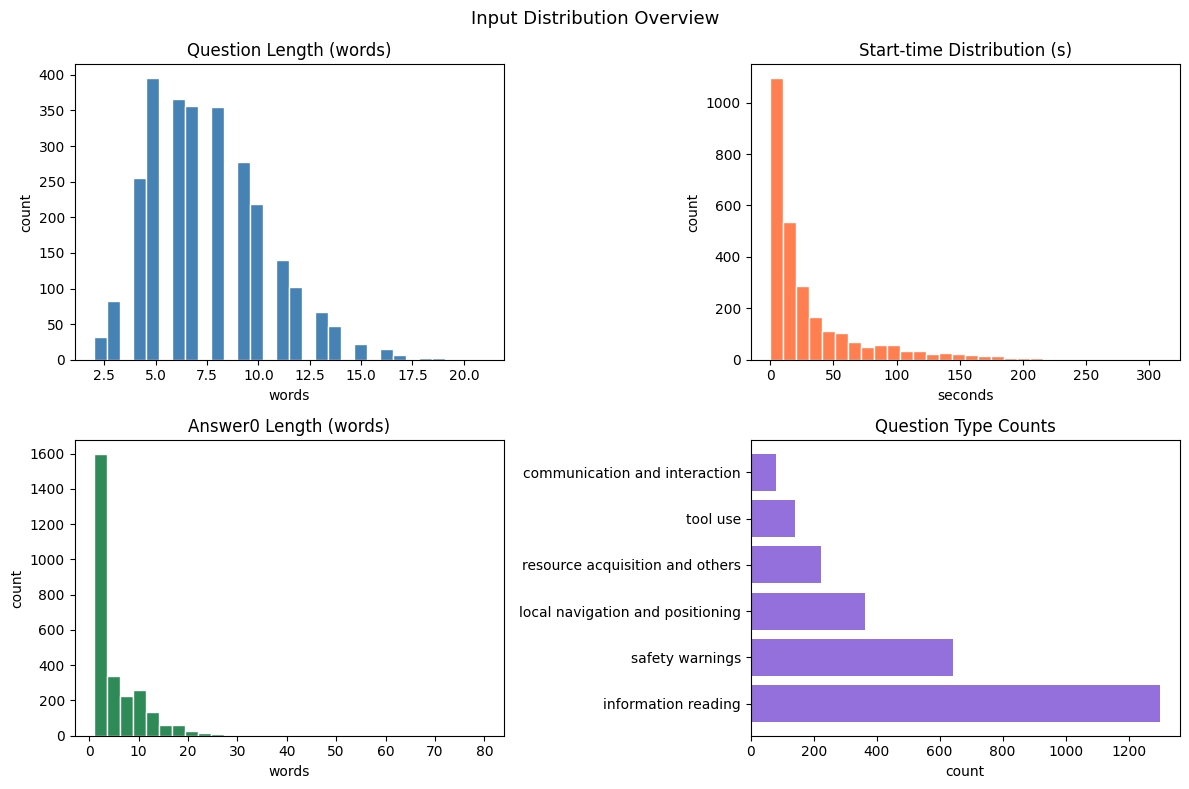

In [ ]:
def visualize_input_distribution(df):
    qlen = df["question"].astype(str).apply(lambda s: len(s.split()))
    st   = pd.to_numeric(df["start-time/s"], errors="coerce")

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Question word-length histogram
    axes[0,0].hist(qlen, bins=30, color="steelblue", edgecolor="white")
    axes[0,0].set_title("Question Length (words)")
    axes[0,0].set_xlabel("words"); axes[0,0].set_ylabel("count")

    # Start-time distribution
    axes[0,1].hist(st.dropna(), bins=30, color="coral", edgecolor="white")
    axes[0,1].set_title("Start-time Distribution (s)")
    axes[0,1].set_xlabel("seconds"); axes[0,1].set_ylabel("count")

    # Answer0 length distribution
    a0len = df["answer0"].astype(str).apply(lambda s: len(s.split()))
    axes[1,0].hist(a0len, bins=30, color="seagreen", edgecolor="white")
    axes[1,0].set_title("Answer0 Length (words)")
    axes[1,0].set_xlabel("words"); axes[1,0].set_ylabel("count")

    # Type counts
    counts = df["type"].value_counts()
    axes[1,1].barh(counts.index.astype(str), counts.values, color="mediumpurple")
    axes[1,1].set_title("Question Type Counts")
    axes[1,1].set_xlabel("count")

    plt.suptitle("Input Distribution Overview", fontsize=13)
    plt.tight_layout()
    plt.savefig("input_distribution.png", dpi=150)
    plt.show()

visualize_input_distribution(df)

(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?
2. Are there any other metrics that could be used here or that you considered?
3. List out the pros and cons of the evaluation metrics you decided to go with.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

1: We will use separate evalutation metrics for the two different models. For the small model whose goal is to determine whether a prompt is urgent or not, we will simply use F1 score. We choose to use F1 score instead of accuracy because the majority of prompts are not urgent, and so using accuracy as a metric would create a perverse incentive for the model to classify most or all prompts as non-urgent.

For the assistant model, we will use LLM-as-a-judge, as outlined in the paper from which we draw the dataset (although with something like Claude Haiku instead of GPT4o-mini like the authors used, since the latter has since been deprecated). The judge will provide each answer with a binary judgement to indicate whether it matches any of the human ground truth answers. Our model will be benchmarked using overall accuracy for this score, because there is no way easy way for it to cheat and make F1 necessary. The judge LLM will also output a score of 0-5 which we will use to determine how similar our model's output is to the ground truth answers, as utility is not simply binary, and partially useful answers are often better than completely useless ones.

For prompts which were judged to be urgent, a latency score will also be used in conjunction with the aforementioned metrics, with quick, accurate responses being rated as more helpful than slow, accurate responses or quick, inaccurate responses.

2: I have considered using other text similarity metrics, like BLEU-1 unigram precision or ROUGE-L or BERTScore, but they are too narrow for the task at hand since it is possible to have similar meaning without exact lexical overlap.

3: The biggest issue by far with our approach is compute cost. Using an LLM to grade every single response will be burn through compute credits, and will be quite slow as well. However, the upside is that it is a powerful and open-ended way to grade responses, that can handle the various nuances of open-ended questions. Additionally, adding latency as a metric in urgent situations will force our model to respond quickly in situations where it is necessary, even if it may slightly impact the quality of responses.

In [ ]:
import time

# LLM-as-Judge: Accuracy + Score (from EgoBlind paper)
# In practice, we would call the Anthropic or OpenAI API here. This function parses the judge's response dict and aggregates over the dataset.
def parse_judge_response(response: dict) -> tuple:
    """
    Parse the LLM judge's output.
    Expected format: {'pred': 'yes' or 'no', 'score': int 0-5}
    Returns (is_correct: bool, score: int)
    """
    is_correct = response.get("pred", "no").strip().lower() == "yes"
    score = int(response.get("score", 0))
    return is_correct, score


def compute_judge_metrics(judge_responses: list[dict]) -> dict:
    """
    Aggregate accuracy and mean score over all judge responses.
    
    Args:
        judge_responses: list of dicts like {'pred': 'yes', 'score': 4}
    Returns:
        dict with 'accuracy' (0-100%) and 'mean_score' (0-5)
    """
    if not judge_responses:
        raise ValueError("No judge responses provided!")
    
    correct = 0
    total_score = 0
    for resp in judge_responses:
        is_correct, score = parse_judge_response(resp)
        correct += int(is_correct)
        total_score += score
    
    n = len(judge_responses)
    return {
        "accuracy": 100.0 * correct / n,
        "mean_score": total_score / n
    }


# Urgency Classifier: F1 Score
def urgency_f1(predictions: list[int], ground_truths: list[int]) -> dict:
    """
    Binary F1 for urgency classification (1=urgent, 0=not urgent).
    Reports precision, recall, and F1 separately since recall
    matters more for safety (missing an urgent query is dangerous).
    """
    tp = sum(p == 1 and g == 1 for p, g in zip(predictions, ground_truths))
    fp = sum(p == 1 and g == 0 for p, g in zip(predictions, ground_truths))
    fn = sum(p == 0 and g == 1 for p, g in zip(predictions, ground_truths))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {"precision": precision, "recall": recall, "f1": f1}


# Latency Measurement (for urgent queries)
def measure_latency(model_fn, inputs: list) -> dict:
    """
    Measures wall-clock response time for a batch of inputs.
    
    Args:
        model_fn: callable that takes a single input and returns a response
        inputs: list of model inputs (e.g., video+question pairs)
    Returns:
        dict with mean, median, and p95 latency in seconds
    """
    latencies = []
    for inp in inputs:
        start = time.perf_counter()
        _ = model_fn(inp)
        elapsed = time.perf_counter() - start
        latencies.append(elapsed)
    
    latencies.sort()
    n = len(latencies)
    return {
        "mean_latency_s":   sum(latencies) / n,
        "median_latency_s": latencies[n // 2],
        "p95_latency_s":    latencies[int(n * 0.95)]
    }


# ============================================================
# Demo
# ============================================================

# Simulated judge responses
demo_judge = [
    {"pred": "yes", "score": 4},
    {"pred": "yes", "score": 5},
    {"pred": "no",  "score": 1},
    {"pred": "yes", "score": 3},
    {"pred": "no",  "score": 0},
]
print("Judge metrics:", compute_judge_metrics(demo_judge))

# Simulated urgency predictions
demo_preds  = [1, 1, 0, 0, 1, 0, 1, 0]
demo_labels = [1, 0, 0, 1, 1, 0, 0, 0]
print("Urgency F1:  ", urgency_f1(demo_preds, demo_labels))

Judge metrics: {'accuracy': 60.0, 'mean_score': 2.6}
Urgency F1:   {'precision': 0.5, 'recall': 0.6666666666666666, 'f1': 0.5714285714285715}


(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. Instruction tuning is creating a prompt that you would feed to a model in order to have it complete a certain assignment by constraing what it can output without the need to train. This is when you prompt the model in specifc ways to guarentee a specific output (e.g. one-word labels, value ranges or classifications). Provide prompts that would be able to guarentee the right output based on the data. **Just provide the prompts, you don't need to train the model.**

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

Scenario 1:

Prompt:
```
You are a sentiment classifier. Given the following restaurant review, respond with exactly one word: "positive", "negative", or "neutral". Do not include any other text.
Review: "This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Sentiment:
```

Scenario 2:

Prompt:
```
You are an emotion recognition model. Look at the face in the image and respond with exactly one of the following labels: "angry", "sad", or "happy". Output only the label.
Emotion:
```

Scenario 3:

Prompt for name:
```
Extract the name of the main subject from the text below. Reply with only the name and nothing else.
Text: "The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."
Name:
```

Prompt for destination:
```
Where is the subject going? Reply with only the destination country's name.
Text: "The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."
Destination:
```

Prompt for activity:
```
What activities was the subject planning to do? Reply with a comma-separated list of activities only.
Text: "The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."
Activities:
```


**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



In [ ]:
# Bonus:

import cv2
import os
import copy
from PIL import Image
from huggingface_hub import snapshot_download
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Downloads full repo so images are available locally
print("Downloading dataset (images + metadata)...")
local_dir = snapshot_download("neuralcatcher/hateful_memes", repo_type="dataset")
print(f"Downloaded to: {local_dir}")

ds = load_dataset("neuralcatcher/hateful_memes", split="train")
print(f"Loaded {len(ds)} memes")

# Extracts image features
def image_features(pil_img):
    img_array = np.array(pil_img.convert("RGB"))
    img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, w = gray.shape
    return [
        w, h, w / max(h, 1),
        gray.mean(), gray.std(),
        hsv[:,:,0].mean(), hsv[:,:,1].mean(), hsv[:,:,2].mean(),
        cv2.Laplacian(gray, cv2.CV_64F).var(),
        cv2.Canny(gray, 100, 200).mean() / 255.0,
    ]

print("Extracting features...")
X_img_list, texts, labels_list = [], [], []
for i in range(len(ds)):
    row = ds[i]
    if not isinstance(row["text"], str) or not row["text"].strip():
        continue
    # Open image from the downloaded local directory
    img_path = os.path.join(local_dir, row["img"])
    if not os.path.exists(img_path):
        continue
    try:
        pil_img = Image.open(img_path)
        feats = image_features(pil_img)
    except Exception:
        continue
    X_img_list.append(feats)
    texts.append(row["text"])
    labels_list.append(row["label"])
    if (i + 1) % 2000 == 0:
        print(f"  Processed {i + 1}/{len(ds)}")

X_img = np.array(X_img_list)
labels = np.array(labels_list)
print(f"Valid samples: {len(texts)}")
print(f"Image features: {X_img.shape}")

# Extracts text features
tfidf = TfidfVectorizer(max_features=300, stop_words="english")
X_text = tfidf.fit_transform(texts).toarray()
print(f"Text features: {X_text.shape}")

# Fuse
X_fused = np.hstack([X_text, X_img])
print(f"Fused features: {X_fused.shape}")
print(f"Labels: {np.bincount(labels)} (0=not-hateful, 1=hateful)")

# Train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_fused, labels, test_size=0.2, random_state=42, stratify=labels
)
n_text = X_text.shape[1]
X_tr_text, X_te_text = X_tr[:, :n_text], X_te[:, :n_text]
X_tr_img,  X_te_img  = X_tr[:, n_text:], X_te[:, n_text:]

# Train & evaluate
scaler = StandardScaler()
results = {}

experiments = {
    "Text only (TF-IDF)":   (X_tr_text, X_te_text),
    "Image only":            (X_tr_img,  X_te_img),
    "Fused (Text + Image)":  (X_tr,      X_te),
}
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
}

for exp_name, (Xtr, Xte) in experiments.items():
    Xtr_s = scaler.fit_transform(Xtr)
    Xte_s = scaler.transform(Xte)
    for model_name, model_template in models.items():
        model = copy.deepcopy(model_template)
        model.fit(Xtr_s, y_tr)
        y_pred = model.predict(Xte_s)
        y_prob = model.predict_proba(Xte_s)[:, 1]
        acc   = accuracy_score(y_te, y_pred)
        f1    = f1_score(y_te, y_pred)
        auroc = roc_auc_score(y_te, y_prob)
        key   = f"{model_name} | {exp_name}"
        results[key] = {"accuracy": f"{acc:.3f}", "f1": f"{f1:.3f}", "auroc": f"{auroc:.3f}"}

# Results
print("\n" + "=" * 72)
print(f"{'Experiment':<45} {'Acc':>7} {'F1':>7} {'AUROC':>7}")
print("=" * 72)
for key, vals in results.items():
    print(f"{key:<45} {vals['accuracy']:>7} {vals['f1']:>7} {vals['auroc']:>7}")
print("=" * 72)

print("\nDetailed report (Logistic Regression | Fused):")
Xtr_s = scaler.fit_transform(X_tr)
Xte_s = scaler.transform(X_te)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(Xtr_s, y_tr)
print(classification_report(y_te, lr.predict(Xte_s), target_names=["not-hateful", "hateful"]))

Fetching ... files: 9672it [09:45, 16.52it/s]


Downloaded to: /Users/xanderbackus/.cache/huggingface/hub/datasets--neuralcatcher--hateful_memes/snapshots/d201c488dc7024623d1ecbcc987b3f132c4c2e12


Repo card metadata block was not found. Setting CardData to empty.


Loaded 8500 memes
Extracting features...
  Processed 4000/8500
  Processed 6000/8500
Valid samples: 6744
Image features: (6744, 10)
Text features: (6744, 300)
Fused features: (6744, 310)
Labels: [4350 2394] (0=not-hateful, 1=hateful)

Experiment                                        Acc      F1   AUROC
Logistic Regression | Text only (TF-IDF)        0.704   0.499   0.699
Random Forest | Text only (TF-IDF)              0.684   0.494   0.658
Logistic Regression | Image only                0.698   0.432   0.704
Random Forest | Image only                      0.673   0.471   0.686
Logistic Regression | Fused (Text + Image)      0.726   0.568   0.763
Random Forest | Fused (Text + Image)            0.718   0.533   0.771

Detailed report (Logistic Regression | Fused):
              precision    recall  f1-score   support

 not-hateful       0.76      0.85      0.80       870
     hateful       0.64      0.51      0.57       479

    accuracy                           0.73      1349
   macro 

For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



Task: I am trying to classify memes as hateful or non-hateful. This is a multimodal task because memes, by their very nature, are multimodal. A meme is a combination of an (usually innocuous) image and a (usually innocuous) text, which together combine to convey a memetic idea which is more than the sum of its parts. For example, a picture of a chimpanzee colony is innocuous on its own, as is the word "Detroit" on its own. However, when the latter is overlaid upon the former, it becomes an offensive and hateful meme.

Dataset: I am using Facebook AI's Hateful Memes dataset (about 8,500 memes), originally introduced at NeurIPS 2020 and loaded from HuggingFace (neuralcatcher/hateful_memes). Needless to say, this is completely separate from the EgoBlind dataset I am using for my term project. After filtering out samples with missing images or empty text, I retained 6,744 usable samples with a roughly 64/36 not-hateful/hateful split.

Modalities: Image and text. Specifically, image features (10 dimensions) extracted via OpenCV: width, height, aspect ratio, mean brightness, brightness standard deviation, mean HSV channels (3), Laplacian variance as a blur proxy, and Canny edge density. These capture low-level visual properties like whether the image is bright, blurry, or visually complex. Text features (300 dimensions) via TF-IDF of the overlaid meme text with Scikit's 'English stop words' removed. This learns which words are distinctive to hateful vs non-hateful memes.

Model: I trained both Logistic Regression and Random Forest models, both using scikit-learn. I chose these because they are fast, interpretable, and require no GPU. They also let us focus on demonstrating the value of multimodal fusion rather than the power of a specific architecture. That is, if even simple classifiers benefit from combining modalities, the principle is clearly validated.

Evaluation: I use accuracy for overall fraction correct. I also use F1 score as the harmonic mean of precision and recall for the hateful class, which is necessary because the dataset is imbalanced (64/36) so accuracy alone could be misleading. I also use AUROC (Area Under the ROC Curve), which was the metric recommended by the original Hateful Memes paper authors. It measures discrimination ability across all classification thresholds, making it robust to class imbalance.

Results: Text-only classification achieved about 70% accuracy and 0.50 F1 with both classifiers. Image-only classification performed similarly at about 70% accuracy but lower F1 around 0.43-0.47. The fused model outperformed both unimodal baselines across all three metrics. The best configuration (Logistic Regression, Fused) achieved 72.6% accuracy, 0.568 F1, and 0.763 AUROC. Notably, text-only and image-only perform similarly to each other, but fusing them yields a clear improvement, confirming that the two modalities carry complementary information. This validates the core multimodal learning principle: heterogeneous data sources, when combined, produce a more complete representation than either alone.

(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.
2. A challenging aspect that you did not expect to deal with and what insights you used to address it.
3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

There is no specific right answer we are looking for, answer how you think!

1: The most interesting topic regarding multimodal learning in my opinion is and always has been how multimodal fusion can lead to the discovery of additional information that is not deducible through the use of any one modality. I know that this is an obvious statement, given how often we ourselves experience it on a daily basis (such as when we shake a box to deduce its contents), but it still interests me from an information theory perspective since it implies that there is some 'hidden' information implicit in each individual modality that requires information from other modalities to act as a sort of 'key' to unlock it.

2: This may be a banal answer, but extracting data from datasets was the most challenging aspect, especially given how Scikit has undergone some changes regarding its structure so older documentation and stack overflow questions are effectively useless. Debugging this actually took up the majority of my implementation time, but the only insight that I gained was that I should be more careful to check for version updates and feature deprecations before trying to use software I am unfamiliar with.

3: I like my dataset because it was created by visually impaired people for visually impaired people. It is much more representative of the video quality and contextual situations that visually impaired people will find themselves in when they need to use a VLM assistant. The only serious issue (besides the fact that some of the ground truth data is withheld by the creators of the dataset) is that the videos are limited in number and scope, especially with regards to dangerous or urgent situations. The vast majority of the videos will not need our new paradigm, and the ones that do oftentimes take a form similar to "Can I cross the street?" which is unfortunate from a research perspective due to the lack of novelty.